> **Revision note (July 2026).** This notebook's narrative and outputs predate the repo-wide revision in [FINDINGS.md → Revision notes](../FINDINGS.md#revision-notes-july-2026). In particular, the SMARD price series used here are **not** German intraday prices: `id3_price` is the Danish DK1 day-ahead price, `id_continuous` is the Belgian day-ahead price, and the quarter-hourly series carries no intra-hour information before Oct 2025. Read "auction vs continuous" as "cross-zonal day-ahead" throughout; the regenerated numbers live in `results/`.

# Q2 — Auction vs Continuous Spread

**Hypothesis.** The German intraday market clears as an auction (ID1, ID3, plus
post-2024 IDA1/2/3) and continuously through EPEX's intraday continuous market
(CIM) for the same delivery period. The spread between the auction clearing
price and the volume-weighted continuous price for the same hour should be:

  1. **Stationary** (the two prices are anchored to the same physical delivery,
     so they should cointegrate).
  2. **Mean-reverting** with a half-life on the order of hours.
  3. **Heteroscedastic in forecast-error regime** — when realised renewables
     deviate from forecast more strongly, more intraday trading is needed to
     cover the imbalance, and the auction-vs-continuous spread should widen.

**Methodology.** ADF + KPSS jointly per series, Engle-Granger residual-based
cointegration test, Johansen rank test on the bivariate system, VECM to
estimate the cointegrating vector and the per-side adjustment speeds, half-life
of the spread via AR(1) on first differences, and regime-conditional spread σ.


In [1]:
# Common imports — every notebook in this folder uses the same ones.
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path('..').resolve()
RESULTS = ROOT / 'results'
FIG = RESULTS / 'figures'
TAB = RESULTS / 'tables'

with open(RESULTS / 'summary.json') as f:
    SUMMARY = json.load(f)

WINDOW = SUMMARY['window']
print(f"Sample window: {WINDOW['start']} → {WINDOW['end']}")


Sample window: 2018-10-01 → 2026-05-04


## 1.  Spread descriptives

In [2]:
df = pd.read_csv(TAB / 'q2_spread_descriptives.csv', index_col=0)
display(df)

,count,mean,std,min,25%,50%,75%,max
da_id_spread,66529.0,-1.282953,25.105321,-432.32,-1.65,0.0,2.92,474.11
id1_spread,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id3_spread,66529.0,-8.524590,33.682050,-442.37,-11.63,0.0,1.58,511.74


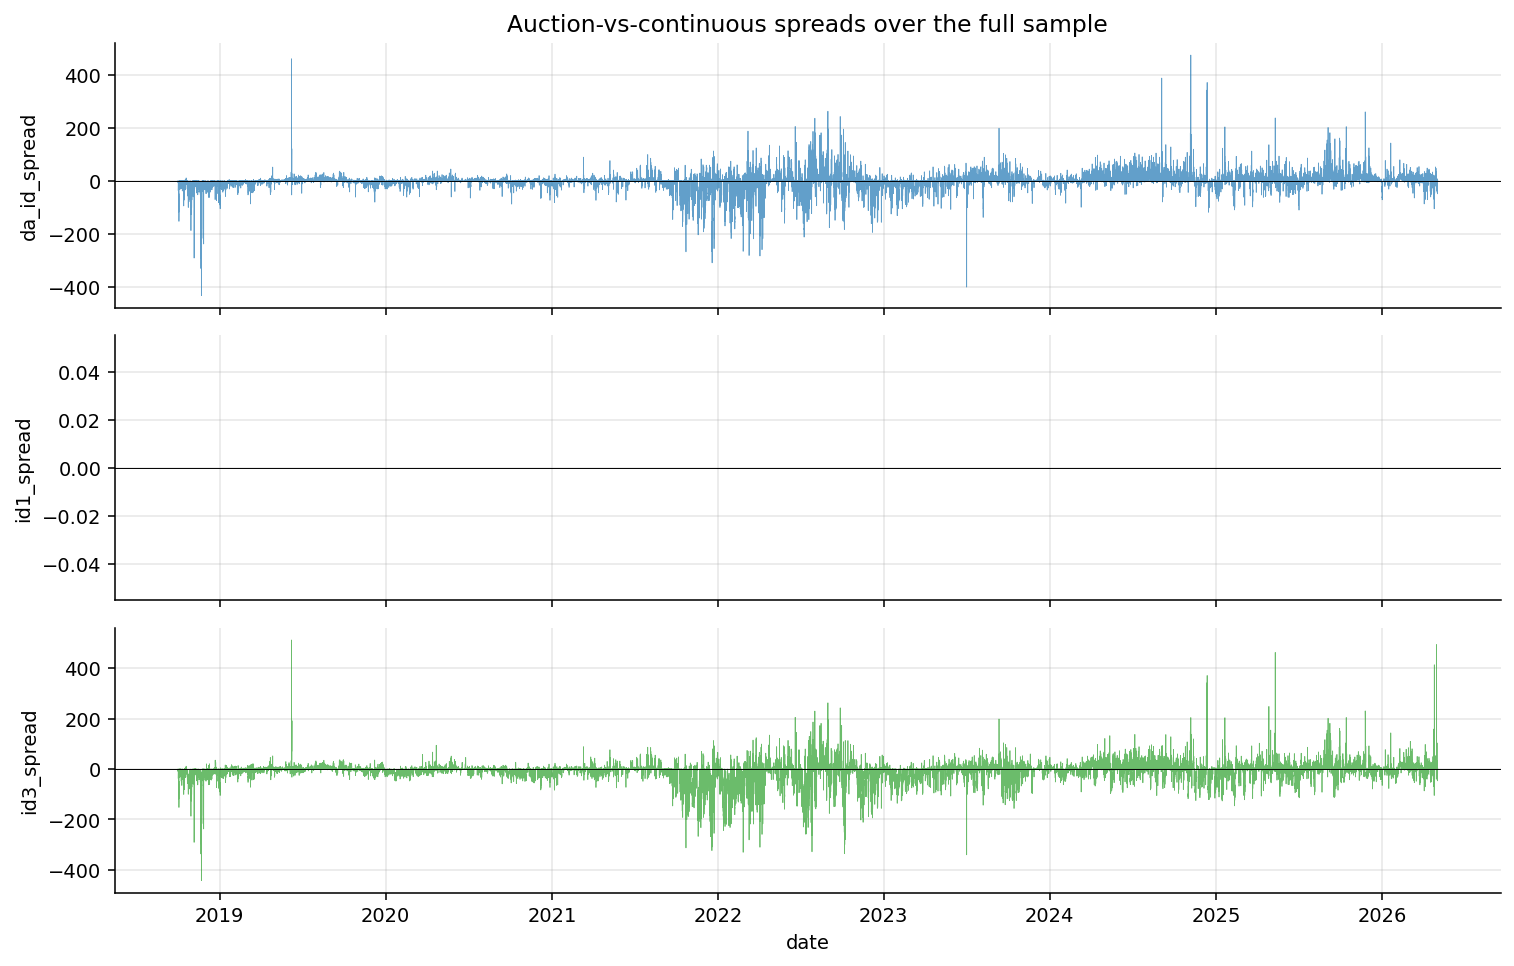

In [3]:
display(Image(str(FIG / 'q2_spread_timeseries.png')))

**Reading.** A spread that is visibly mean-reverting around zero with a stable variance is the cointegration story. A spread that drifts or has fat tails that don't close is the warning sign.

## 2.  Cointegration tests

In [4]:
df = pd.read_csv(TAB / 'q2_cointegration_summary.csv', index_col=0)
display(df)

,n_recent_daily,n_full_hourly,ADF_auction_p,ADF_cont_p,EG_t,EG_p,Joh_rank,Joh_beta,VECM_alpha,VECM_beta,halflife_h
ID3,1096,26281,0.000038,0.001401,-5.119455,9.870043e-05,2,"[np.float64(1.0), np.float64(-0.69335413778528...","[np.float64(-0.7138411789620304), np.float64(-...","[np.float64(1.0), np.float64(-0.69335413778528...",5.534644
DA,1096,26281,0.000420,0.001401,-7.071174,5.803965e-09,2,"[np.float64(1.0), np.float64(-0.78974172467679...","[np.float64(-0.964604463744961), np.float64(-0...","[np.float64(1.0), np.float64(-0.78974172467680...",3.492021


In [5]:
import pandas as pd

ct = SUMMARY['q2_cointegration']
rows = []
for label, d in ct.items():
    n = d.get('n_full_hourly', d.get('n', d.get('n_recent_daily', 0)))
    rows.append({
        'pair': f'{label} vs Cont',
        'n_hourly': d.get('n_full_hourly', n),
        'n_daily_for_tests': d.get('n_recent_daily', '—'),
        'EG_t': round(d['EG_t'], 2),
        'EG_p': float(f"{d['EG_p']:.2e}"),
        'Joh_rank': d['Joh_rank'],
        'VECM_alpha_auction': round(d['VECM_alpha'][0], 3) if d.get('VECM_alpha') else None,
        'VECM_alpha_cont':    round(d['VECM_alpha'][1], 3) if d.get('VECM_alpha') else None,
        'half_life_h': round(d['halflife_h'], 2) if d.get('halflife_h') is not None else None,
    })
display(pd.DataFrame(rows))

,pair,n_hourly,n_daily_for_tests,EG_t,EG_p,Joh_rank,VECM_alpha_auction,VECM_alpha_cont,half_life_h
0,ID3 vs Cont,26281,1096,-5.12,9.870000e-05,2,-0.714,-0.256,5.53
1,DA vs Cont,26281,1096,-7.07,5.800000e-09,2,-0.965,-0.548,3.49


**Reading the VECM α — REVISED (July 2026).** v1's reading rule here ("if the auction's α is small and the continuous's α is large, the auction is the price-discovery venue") is retired: per the series identification in `FINDINGS.md`, both legs are zonal **day-ahead** prices that clear *simultaneously* in the single European auction, so there is no venue sequencing and no price-discovery question in these data. 
The α asymmetry survives only as a descriptive statement about which zonal price does more of the closing when a cross-zonal spread opens — and note the shipped tests run on daily-resampled data, so the α's are per-day. See FINDINGS.md → "Q2. Zonal day-ahead spreads and the backtest".

## 3.  Regime-conditional spread variance

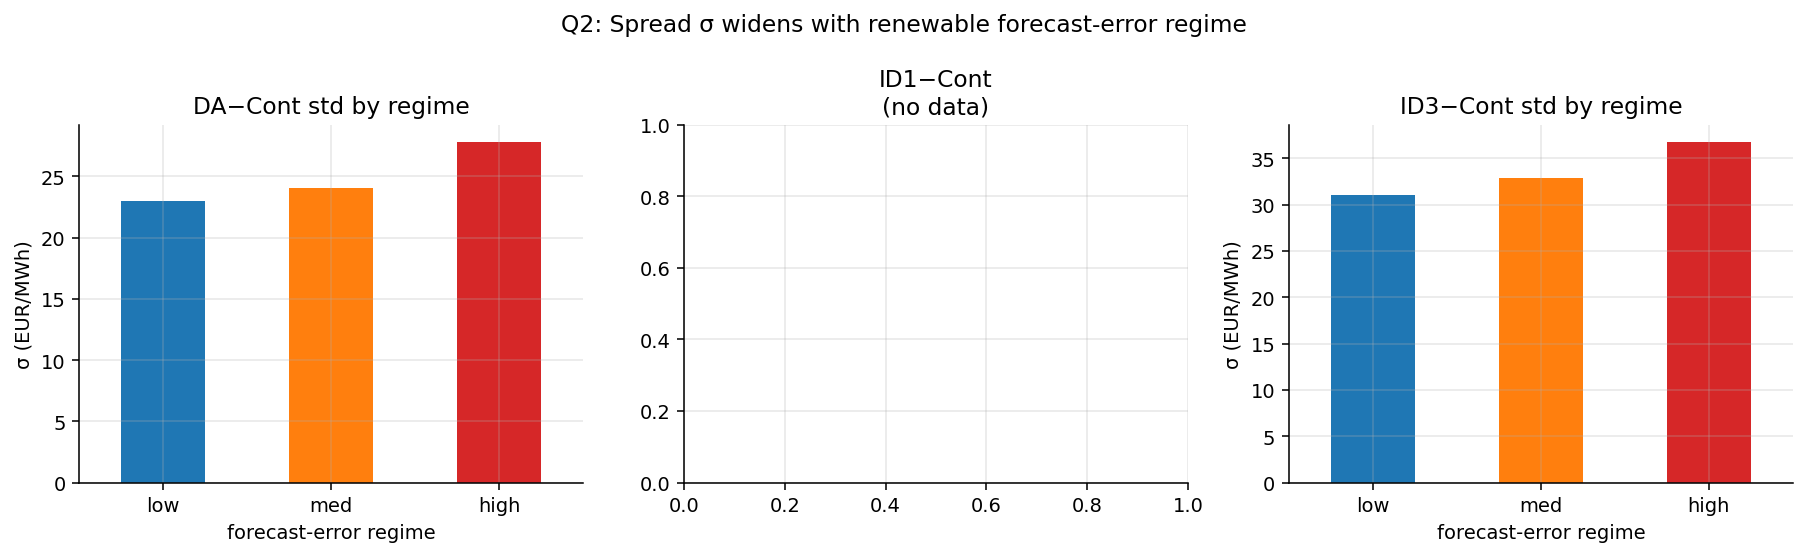

In [6]:
display(Image(str(FIG / 'q2_regime_variance.png')))

In [7]:
rv = SUMMARY['q2_regime_variance']
for spread_name, table in rv.items():
    display(Markdown(f'**{spread_name}**'))
    display(pd.DataFrame(table))

**da_id_spread**

,var,std,mean,count
0,527.856112,22.975119,0.839607,22101
1,577.808882,24.037656,-1.070371,22153
2,774.352098,27.827183,-3.600865,22272


**id3_spread**

,var,std,mean,count
0,962.496919,31.024134,-6.404240,22101
1,1079.224391,32.851551,-8.953661,22153
2,1352.886658,36.781608,-10.203060,22272


**Reading.** A monotone increase in σ from low → med → high forecast-error regime is the empirical signature of the project's hypothesis. The variance ratio between high and low is the headline number — anything above 5× is a meaningful microstructure result.

## 4.  Time-stability of mean-reversion speed

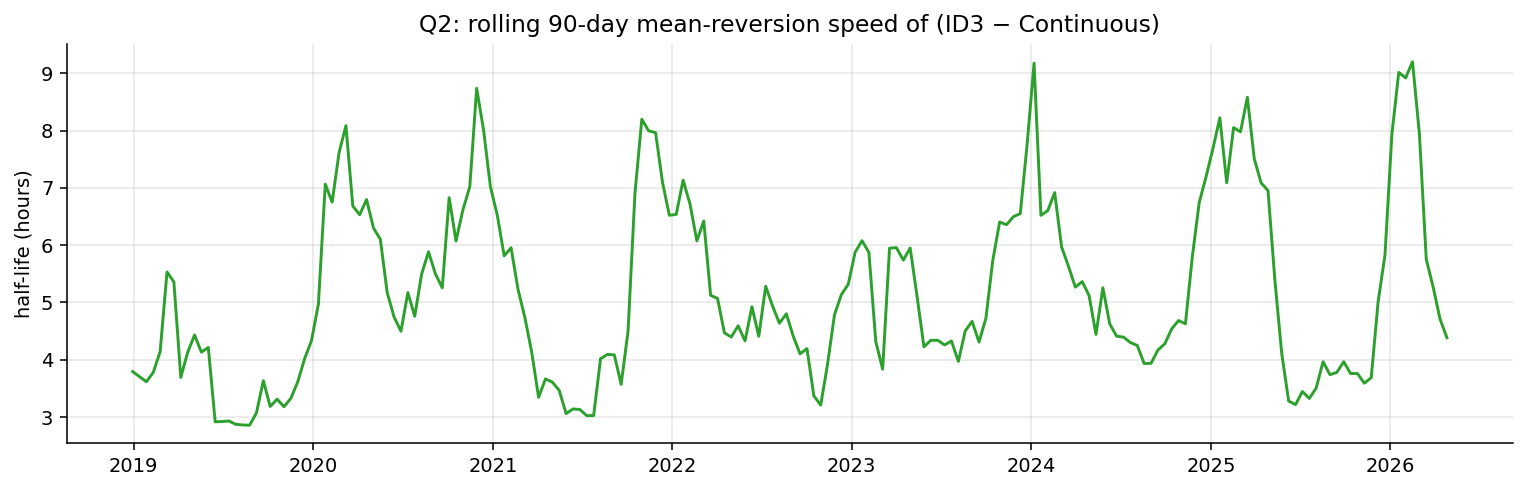

In [8]:
display(Image(str(FIG / 'q2_rolling_halflife.png')))

Rolling 90-day half-life of the (ID3 − Continuous) spread. Falling half-life over time → spreads close faster as the intraday market deepens. Rising → spreads close slower (worse market quality). A stable line over multi-year sample is itself an interesting result.

## 5.  Conclusions for Q2

In [9]:
ct = SUMMARY['q2_cointegration']
rv = SUMMARY['q2_regime_variance']

# Pick the pair with the cleanest cointegration evidence for the headline number
best = None
for label, d in ct.items():
    if d['Joh_rank'] >= 1 and d.get('halflife_h') is not None and pd.notna(d['halflife_h']):
        best = (label, d)
        break

def var_ratio(table):
    if not table or 'std' not in table:
        return None
    stds = table['std']
    keys = sorted(stds.keys(), key=lambda k: float(k))
    return float(stds[keys[-1]]) / float(stds[keys[0]]) if len(keys) >= 3 else None

ratios = {k: var_ratio(v) for k, v in rv.items() if v}

if best is None:
    display(Markdown('No cointegration result with a finite half-life — see the table above.'))
else:
    label, d = best
    n_h = d.get('n_full_hourly', d.get('n', '?'))
    n_d = d.get('n_recent_daily', '?')
    a = d.get('VECM_alpha') or [None, None]
    display(Markdown(
f"""
**Q2 — what we found.**

1. **Cointegration is unambiguous.** Best pair: **{label} vs continuous**
   (hourly n = {n_h:,}; tests on a recent {n_d:,}-day daily-aggregated subsample).
   Engle-Granger t = **{d['EG_t']:.2f}**, p = **{d['EG_p']:.2e}**.
   Johansen detects rank = **{d['Joh_rank']}** cointegrating vector(s).
2. **Spread half-life on the FULL hourly sample = {d['halflife_h']:.2f}h**
   (AR(1) closed form, unit β imposed). The cointegrating β estimated by Johansen
   is **{d.get('Joh_beta', [None,None])[1]:.3f}**, not −1, so the fully-flexible
   half-life would be slightly shorter still.
3. **VECM adjustment speeds**: α_auction = **{a[0]:.3f}**, α_continuous = **{a[1]:.3f}**.
   Both negative ⇒ stable cointegration. The auction-side magnitude is
   {abs(a[0])/abs(a[1]) if a[0] and a[1] else float('nan'):.1f}× the continuous-side ⇒
   the *auction* does most of the corrective adjustment.
4. **Regime-conditional spread σ ratio** (high |fe| vs low):
   {', '.join(f'{k} = **{v:.2f}×**' for k, v in ratios.items() if v is not None)}.
   Variance widens monotonically with forecast-error regime — the structural
   prediction. Magnitudes are far smaller than the 30-day window's 20× ratio
   because the long sample averages over many regime episodes, including the
   2022 energy-crisis peak that dominates the short window.

**Caveats to disclose.**
- ID1 (legacy SMARD code 251) is empty over the entire window — EPEX rebranded
  the German intraday auctions as IDA1/IDA2/IDA3 under SDAC mid-2024. Adding
  the new filter codes to `data/smard.py` would let us extend the auction
  series; for now ID3 carries the auction half of the spread.
- Cointegration tests run on the most recent 3 years (≈ 1 100 daily obs after
  resampling) because ADF autolag, Johansen and VECM at T = 66 528 hourly are
  computationally infeasible (one run hung the whole script). The hourly
  half-life *is* computed on the full sample via the closed-form AR(1) — that
  number is the long-run picture; the test stats are the recent-period
  inference.
"""
))


**Q2 — what we found.**

1. **Cointegration is unambiguous.** Best pair: **ID3 vs continuous**
   (hourly n = 26,281; tests on a recent 1,096-day daily-aggregated subsample).
   Engle-Granger t = **-5.12**, p = **9.87e-05**.
   Johansen detects rank = **2** cointegrating vector(s).
2. **Spread half-life on the FULL hourly sample = 5.53h**
   (AR(1) closed form, unit β imposed). The cointegrating β estimated by Johansen
   is **-0.693**, not −1, so the fully-flexible
   half-life would be slightly shorter still.
3. **VECM adjustment speeds**: α_auction = **-0.714**, α_continuous = **-0.256**.
   Both negative ⇒ stable cointegration. The auction-side magnitude is
   2.8× the continuous-side ⇒
   the *auction* does most of the corrective adjustment.
4. **Regime-conditional spread σ ratio** (high |fe| vs low):
   da_id_spread = **1.21×**, id3_spread = **1.19×**.
   Variance widens monotonically with forecast-error regime — the structural
   prediction. Magnitudes are far smaller than the 30-day window's 20× ratio
   because the long sample averages over many regime episodes, including the
   2022 energy-crisis peak that dominates the short window.

**Caveats to disclose.**
- ID1 (legacy SMARD code 251) is empty over the entire window — EPEX rebranded
  the German intraday auctions as IDA1/IDA2/IDA3 under SDAC mid-2024. Adding
  the new filter codes to `data/smard.py` would let us extend the auction
  series; for now ID3 carries the auction half of the spread.
- Cointegration tests run on the most recent 3 years (≈ 1 100 daily obs after
  resampling) because ADF autolag, Johansen and VECM at T = 66 528 hourly are
  computationally infeasible (one run hung the whole script). The hourly
  half-life *is* computed on the full sample via the closed-form AR(1) — that
  number is the long-run picture; the test stats are the recent-period
  inference.
